<a href="https://colab.research.google.com/github/propulse-7969/UGP-ML-x-Catalysis/blob/main/EDA_CDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_excel("../data/Combined_Data_Categorized.xlsx")

In [3]:
df.columns

Index(['Temperature (°C)', 'GHSV (ml/(h*g))', 'CH₄ concentration (%)',
       'Time (min)', 'Calcined temperature (°C)', 'Fe (wt%)', 'Ni (wt%)',
       'Cu (wt%)', 'Co (wt%)', 'Mo (wt%)', 'Al₂O₃ (wt%)', 'SiO₂ (wt%)',
       'TiO₂ (wt%)', 'MgO (wt%)', 'CNT (wt%)', 'CeZrO2 (wt%)',
       'CH₄ conversion (%)', 'H₂ yield (%)'],
      dtype='str')

In [4]:
df = df.rename(columns={
    'Temperature (°C)': 'temp_C',
    'GHSV (ml/(h*g))': 'ghsv',
    'CH₄ concentration (%)': 'ch4_conc_pct',
    'Time (min)': 'time_min',
    'Calcined temperature (°C)': 'calc_temp_C',
    
    'Fe (wt%)': 'fe_wt',
    'Ni (wt%)': 'ni_wt',
    'Cu (wt%)': 'cu_wt',
    'Co (wt%)': 'co_wt',
    'Mo (wt%)': 'mo_wt',
    
    'Al₂O₃ (wt%)': 'al2o3_wt',
    'SiO₂ (wt%)': 'sio2_wt',
    'TiO₂ (wt%)': 'tio2_wt',
    'MgO (wt%)': 'mgo_wt',
    'CNT (wt%)': 'cnt_wt',
    'CeZrO2 (wt%)': 'cezro2_wt',
    
    'CH₄ conversion (%)': 'ch4_conversion_pct',
    'H₂ yield (%)': 'h2_yield_pct'
})

df.columns

Index(['temp_C', 'ghsv', 'ch4_conc_pct', 'time_min', 'calc_temp_C', 'fe_wt',
       'ni_wt', 'cu_wt', 'co_wt', 'mo_wt', 'al2o3_wt', 'sio2_wt', 'tio2_wt',
       'mgo_wt', 'cnt_wt', 'cezro2_wt', 'ch4_conversion_pct', 'h2_yield_pct'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temp_C              698 non-null    int64  
 1   ghsv                698 non-null    int64  
 2   ch4_conc_pct        698 non-null    float64
 3   time_min            698 non-null    float64
 4   calc_temp_C         698 non-null    int64  
 5   fe_wt               698 non-null    float64
 6   ni_wt               698 non-null    float64
 7   cu_wt               698 non-null    int64  
 8   co_wt               698 non-null    float64
 9   mo_wt               698 non-null    int64  
 10  al2o3_wt            698 non-null    float64
 11  sio2_wt             698 non-null    int64  
 12  tio2_wt             698 non-null    int64  
 13  mgo_wt              698 non-null    float64
 14  cnt_wt              698 non-null    float64
 15  cezro2_wt           698 non-null    int64  
 16  ch4_conversion_pct 

In [6]:
df = df.drop(columns=["cu_wt","tio2_wt"])

In [7]:
df = df.replace("-", np.nan)

In [8]:
df["ch4_conversion_pct"] = pd.to_numeric(df["ch4_conversion_pct"], errors="coerce")
df["h2_yield_pct"] = pd.to_numeric(df["h2_yield_pct"], errors="coerce")

In [9]:
df = df.dropna(subset=["h2_yield_pct"])

In [10]:
df = df.reset_index(drop=True)

In [11]:
df = df.fillna(df.median(numeric_only=True))

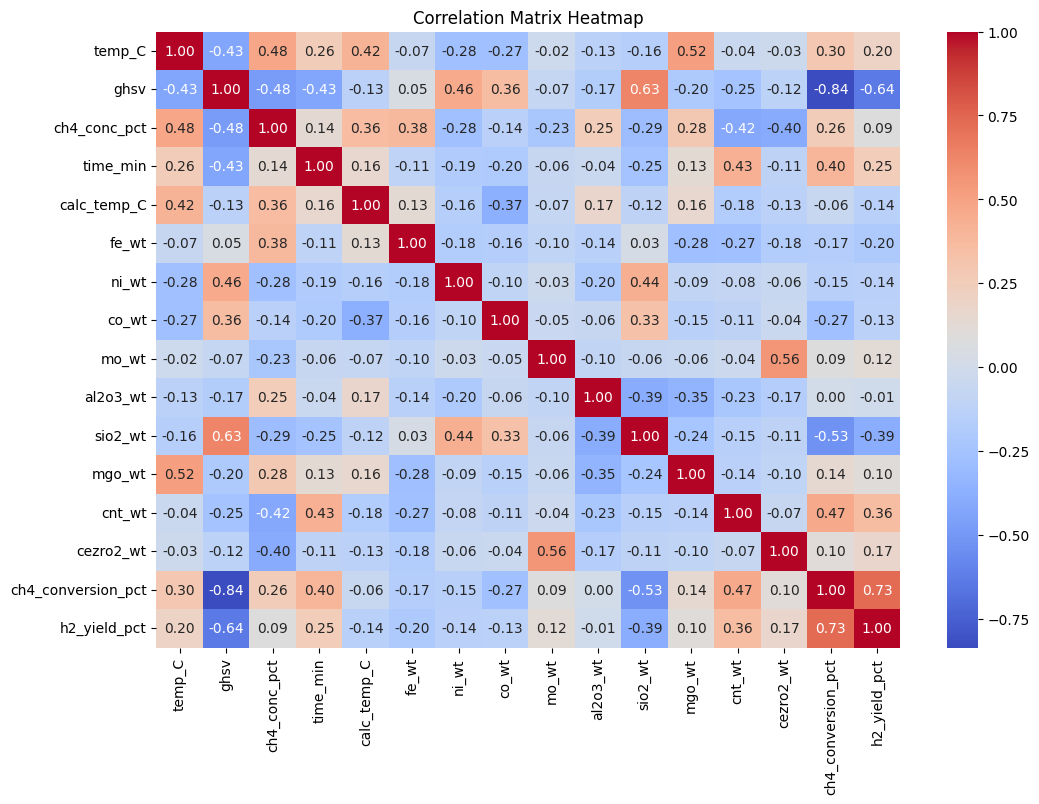

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

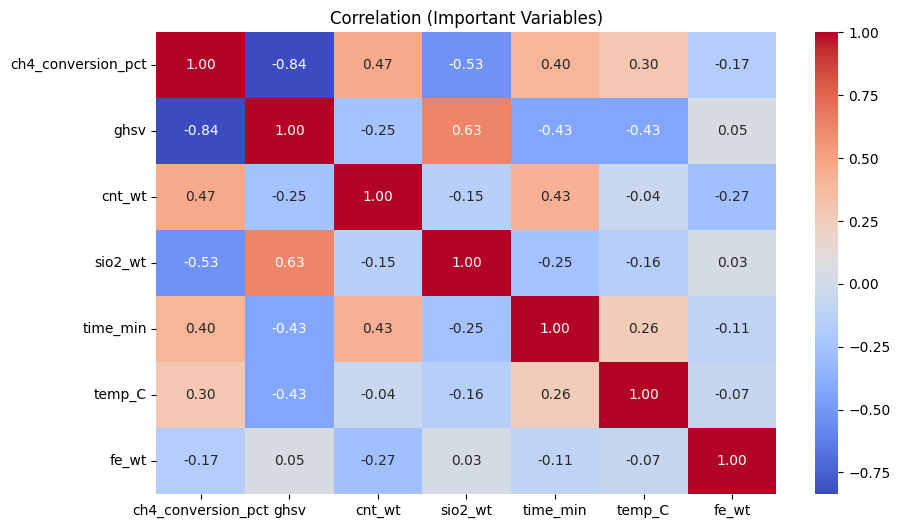

In [13]:
selected_features = [
    'ch4_conversion_pct',
    'ghsv',
    'cnt_wt',
    'sio2_wt',
    'time_min',
    'temp_C',
    'fe_wt'
]

corr_subset = df[selected_features].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_subset, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation (Important Variables)")
plt.show()

First We build a model based on all the features

In [14]:
X=df.drop(columns=["h2_yield_pct", "ch4_conversion_pct"])
y=df["h2_yield_pct"]

In [15]:
print(df["h2_yield_pct"].isnull().sum())

0


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
rf = RandomForestRegressor(
    n_estimators=200,   
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [18]:
y_pred = rf.predict(X_test)

In [19]:
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9688074939596311
RMSE: 4.498586301390568


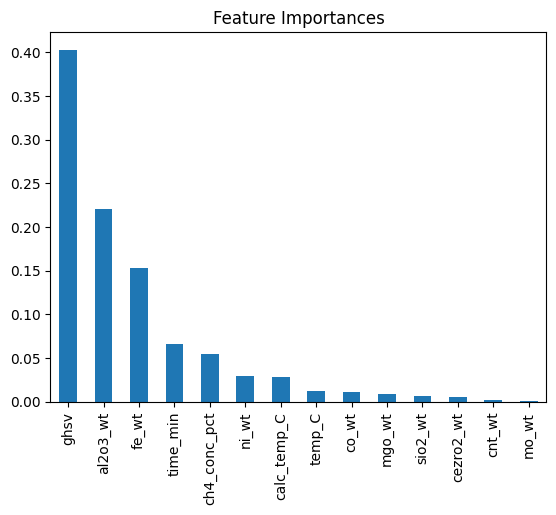

In [20]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importances")
plt.show()

c:\Users\omutk\UGP-ML-x-Catalysis\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\omutk\UGP-ML-x-Catalysis\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


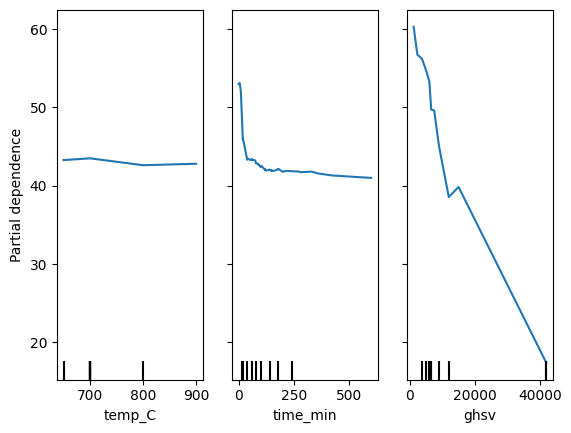

In [21]:
from sklearn.inspection import PartialDependenceDisplay

features_to_plot = ['temp_C', 'time_min', 'ghsv']

PartialDependenceDisplay.from_estimator(rf, X, features_to_plot)
plt.show()

Model Screening

In [22]:
!pip install xgboost

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor


In [24]:
import matplotlib.pyplot as plt
import numpy as np

models = {
    "RF": RandomForestRegressor(),
    "DT": DecisionTreeRegressor(),
    "KNN": KNeighborsRegressor(),
    "XGB": XGBRegressor()
}

predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

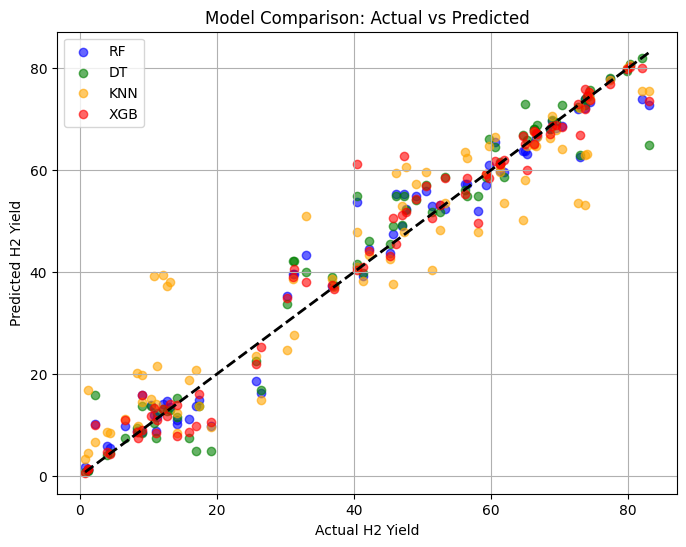

In [25]:
plt.figure(figsize=(8,6))

colors = {
    "RF": "blue",
    "DT": "green",
    "KNN": "orange",
    "XGB": "red"
}

for name, y_pred in predictions.items():
    plt.scatter(y_test, y_pred, label=name, alpha=0.6, color=colors[name])

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel("Actual H2 Yield")
plt.ylabel("Predicted H2 Yield")
plt.title("Model Comparison: Actual vs Predicted")
plt.legend()
plt.grid(True)

plt.show()

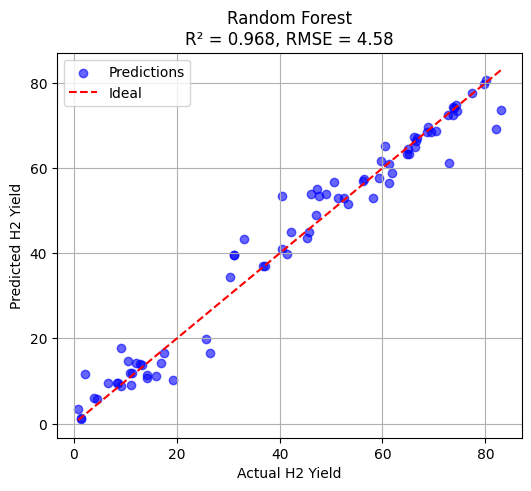

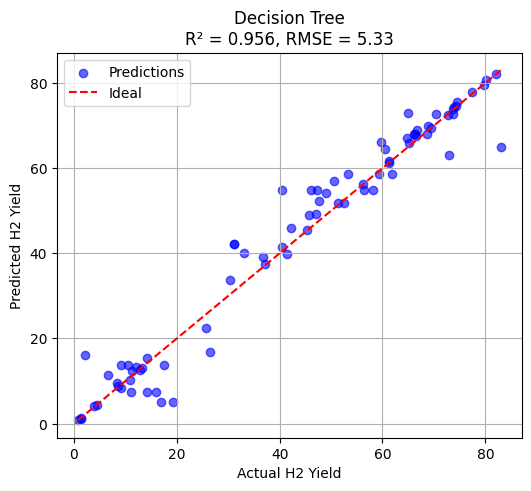

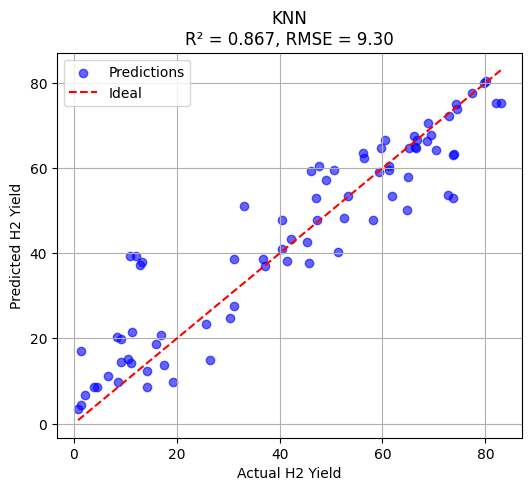

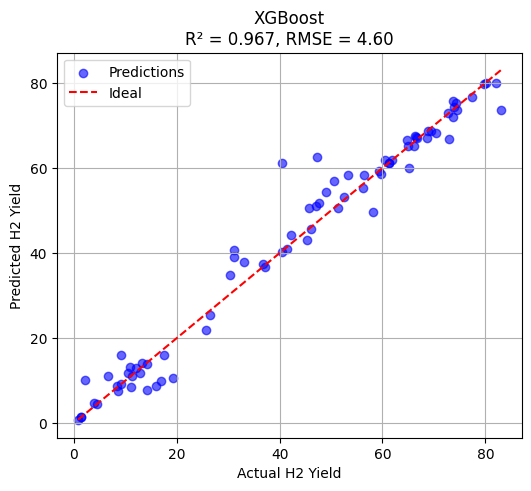

In [26]:
from sklearn.metrics import r2_score, mean_squared_error

models = {
    "Random Forest": RandomForestRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "KNN": KNeighborsRegressor(),
    "XGBoost": XGBRegressor()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    plt.figure(figsize=(6,5))
    
    plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predictions')
    
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
    
    plt.xlabel("Actual H2 Yield")
    plt.ylabel("Predicted H2 Yield")
    plt.title(f"{name}\nR² = {r2:.3f}, RMSE = {rmse:.2f}")
    
    plt.legend()
    plt.grid(True)
    plt.show()

XGBOOST APPROACH

In [27]:
xgb = XGBRegressor()
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [28]:
y_pred_xgb = xgb.predict(X_test)

In [29]:
print("R2 Score:", r2_score(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

R2 Score: 0.9673654357776942
RMSE: 4.601398339541151
